# Energy Model Calibration (DESNZ vs ABM)

Self-contained calibration: load ABM outputs, load DESNZ LSOA elec+gas, compare per-dwelling (ABM per UPRN) to DESNZ per-meter, and plot distributions by year.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# display options
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)


## Paths and settings
Edit these as needed. `RUN_MODEL` defaults to False (use existing outputs).

In [2]:
# Data paths (relative to repo root)
GEOJSON     = Path('../data/epc_abm_newcastle.geojson')
CLIMATE     = Path('../data/ncc_2t_timeseries_2010_2039.parquet')
HIDP_CSV    = Path('../data/hidp_uprn_matches_tiered.csv')
ELEC_XLSX   = Path('../data/LSOA_domestic_elec_2010-2023.xlsx')
GAS_XLSX    = Path('../data/LSOA_domestic_gas_2010-2023.xlsx')
OUTDIR      = Path('results/calibration')
OUTDIR.mkdir(parents=True, exist_ok=True)

# Model outputs (produced separately via run.py)
MODEL_PARQUET = OUTDIR / 'model_timeseries.parquet'
AGENT_PARQUET = OUTDIR / 'agent_timeseries.parquet'

RUN_MODEL = False           # set True to rerun long model here (slow)
START_UTC = '2020-01-01T00:00:00Z'
YEARS = [2020, 2021, 2022, 2023]
LSOA_COL = 'lsoa_code'


## Load GeoJSON + HIDP enrichment (coalesce duplicate area codes)

In [3]:
gdf = gpd.read_file(GEOJSON)
print(f"Loaded {len(gdf):,} dwellings from {GEOJSON}")

# ensure UPRN
if 'UPRN' not in gdf.columns:
    for alt in ['uprn','fid']:
        if alt in gdf.columns:
            gdf['UPRN'] = gdf[alt]
            break
assert 'UPRN' in gdf.columns, 'No UPRN field found.'
gdf['UPRN'] = gdf['UPRN'].astype(str).str.strip()

# HIDP merge (optional)
if HIDP_CSV.exists():
    hidp_df = pd.read_csv(HIDP_CSV, low_memory=False)
    hidp_df.columns = [c.strip() for c in hidp_df.columns]
    hidp_df['uprn_chr'] = hidp_df['uprn_chr'].astype(str).str.strip()
    hidp_df = hidp_df.drop_duplicates('uprn_chr')
    before = len(gdf)
    gdf = gdf.merge(hidp_df, how='left', left_on='UPRN', right_on='uprn_chr', suffixes=('_geo','_hidp'))
    print(f"Merged HIDP: {before:,} -> {len(gdf):,}; unmatched: {gdf['uprn_chr'].isna().sum():,}")
    # coalesce lsoa if duplicated
    if 'lsoa_code_geo' in gdf.columns or 'lsoa_code_hidp' in gdf.columns:
        gdf['lsoa_code'] = gdf.get('lsoa_code_geo').combine_first(gdf.get('lsoa_code_hidp'))
        gdf.drop(columns=[c for c in ['lsoa_code_geo','lsoa_code_hidp'] if c in gdf.columns], inplace=True)
else:
    print('Skipping HIDP enrichment (file not found)')

assert LSOA_COL in gdf.columns, f"{LSOA_COL} not found after merge"


Loaded 97,714 dwellings from ../data/epc_abm_newcastle.geojson
Merged HIDP: 97,714 -> 97,714; unmatched: 440


## Optional: run model (slow) or load existing outputs
If `RUN_MODEL=False`, ensure `model_timeseries.parquet` and `agent_timeseries.parquet` exist in OUTDIR.


## Optional: run per-LSOA batch (ABM → annual per-dwelling)

In [4]:
# Toggle to run per-LSOA batch simulations (writes to results_lsoa)
RUN_LSOA_BATCH = True
LSOA_BATCH_CODES = None  # e.g., ['E01035614', 'E01008358']; None = all LSOAs in GEOJSON
LSOA_BATCH_OUTDIR = Path('results_lsoa')
LSOA_BATCH_MAX_PROCS = 4
END_UTC = '2025-01-01T00:00:00Z'  # batch end time (exclusive)


In [5]:
# Convenience: pick the largest 20 LSOAs by dwelling count for quick tests
if 'FILTER_TOP20_LSOA' not in globals():
    FILTER_TOP20_LSOA = False
FILTER_TOP20_LSOA = True
if FILTER_TOP20_LSOA:
    lsoa_counts = gdf.groupby(LSOA_COL)['UPRN'].nunique().sort_values(ascending=False)
    LSOA_BATCH_CODES = list(lsoa_counts.head(5).index)
    print(f"Selected top {len(LSOA_BATCH_CODES)} LSOAs by dwellings: {LSOA_BATCH_CODES[:5]}...")


Selected top 5 LSOAs by dwellings: ['E01035614', 'E01008458', 'E01033547', 'E01033545', 'E01008358']...


In [6]:
import multiprocessing as mp
from household_energy.run_lsoa_batch import RunConfig, _run_single_lsoa


def run_lsoa_batch(lsoas=None, max_procs=LSOA_BATCH_MAX_PROCS):
    stamp = pd.Timestamp.utcnow().strftime('%Y%m%d')
    cfg = RunConfig(
        geojson=GEOJSON,
        climate=CLIMATE,
        hidp_csv=HIDP_CSV if HIDP_CSV.exists() else None,
        start_utc=START_UTC,
        end_utc=END_UTC,
        days=None,
        local_tz='Europe/London',
        lsoa_col=LSOA_COL,
        outdir=LSOA_BATCH_OUTDIR,
        agent_collect_every=1,
        stamp=stamp,
    )
    gdf_all = gpd.read_file(GEOJSON)
    all_lsoas = sorted(gdf_all[LSOA_COL].astype(str).unique())
    target_lsoas = list(lsoas) if lsoas is not None else list(all_lsoas)
    total = len(target_lsoas)
    print(f"Running {total} LSOAs → {cfg.outdir} (stamp {stamp})")
    cfg.outdir.mkdir(parents=True, exist_ok=True)

    tasks = [(lsoa, cfg, i + 1, total) for i, lsoa in enumerate(target_lsoas)]
    if max_procs == 1:
        rows = [_run_single_lsoa(*task) for task in tasks]
    else:
        try:
            with mp.Pool(processes=max(1, max_procs)) as pool:
                rows = pool.starmap(_run_single_lsoa, tasks)
        except RuntimeError as e:
            print(f"Pool failed ({e}); falling back to serial.")
            rows = [_run_single_lsoa(*task) for task in tasks]

    annual_all = pd.concat([r for r in rows if r is not None], ignore_index=True)
    if not annual_all.empty:
        stamp_path = cfg.outdir / f"abm_year_all_{cfg.stamp}.parquet"
        annual_all.to_parquet(stamp_path, index=False)
        annual_all.to_csv(cfg.outdir / f"abm_year_all_{cfg.stamp}.csv", index=False)
        print(f"Saved combined annual table → {stamp_path.name}")
    return annual_all

if RUN_LSOA_BATCH:
    abm_year_batch = run_lsoa_batch(LSOA_BATCH_CODES, max_procs=LSOA_BATCH_MAX_PROCS)
    display(abm_year_batch.head())


Running 5 LSOAs → results_lsoa (stamp 20260130)
[3/5] LSOA E01033547 – loading dwellings…
[2/5] LSOA E01008458 – loading dwellings…
[1/5] LSOA E01035614 – loading dwellings…
[4/5] LSOA E01033545 – loading dwellings…
    step 4,384/43,848 ( 10%) for E01033545
    step 4,384/43,848 ( 10%) for E01033547
    step 4,384/43,848 ( 10%) for E01008458
    step 4,384/43,848 ( 10%) for E01035614
    step 8,768/43,848 ( 20%) for E01033545
    step 8,768/43,848 ( 20%) for E01033547
    step 8,768/43,848 ( 20%) for E01008458
    step 13,152/43,848 ( 30%) for E01033545
    step 8,768/43,848 ( 20%) for E01035614
    step 13,152/43,848 ( 30%) for E01033547
    step 17,536/43,848 ( 40%) for E01033545
    step 13,152/43,848 ( 30%) for E01008458
    step 13,152/43,848 ( 30%) for E01035614
    step 17,536/43,848 ( 40%) for E01033547
    step 21,920/43,848 ( 50%) for E01033545
    step 17,536/43,848 ( 40%) for E01008458
    step 26,304/43,848 ( 60%) for E01033545
    step 21,920/43,848 ( 50%) for E01033547


,abm_kwh,year,lsoa_code,run_dwellings,abm_kwh_per_dw
0,2.099544e+07,2020,E01035614,1394,15061.294397
1,2.063383e+07,2021,E01035614,1394,14801.887344
2,2.183770e+07,2022,E01035614,1394,15665.493144
3,2.165678e+07,2023,E01035614,1394,15535.711435
4,2.126523e+07,2024,E01035614,1394,15254.827519


## Load DESNZ LSOA data (elec + gas)

In [7]:
import re

NORM_COLMAP = {
    "Local authority code": "la_code",
    "Local authority": "local_authority",
    "MSOA code": "msoa_code",
    "Middle layer super output area": "msoa_name",
    "LSOA code": "lsoa_code",
    "Lower layer super output area": "lsoa_name",
    "Number of meters": "meters",
    "Total consumption (kWh)": "total_kwh",
    "Mean consumption (kWh per meter)": "mean_kwh",
    "Median consumption (kWh per meter)": "median_kwh",
}

def tidy_lsoa(xlsx_path: Path, fuel: str) -> pd.DataFrame:
    book = pd.read_excel(xlsx_path, sheet_name=None, header=4, engine='openpyxl')
    # drop first sheet (notes)
    first = next(iter(book))
    book.pop(first, None)
    frames = []
    for sheet_name, df in book.items():
        df = df.copy()
        df.columns = df.columns.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        df = df.rename(columns={k: v for k, v in NORM_COLMAP.items() if k in df.columns})
        wanted = ["lsoa_code","lsoa_name","meters","total_kwh"]
        keep = [c for c in wanted if c in df.columns]
        if not keep:
            continue
        df = df[keep].copy()
        for c in {"meters","total_kwh"} & set(keep):
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','',regex=False), errors='coerce')
        m = re.search(r"(20\d{2})", str(sheet_name))
        if not m:
            continue
        df["year"] = int(m.group(1))
        df["fuel"] = fuel
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["year","fuel","lsoa_code","meters","total_kwh"])
    out = pd.concat(frames, ignore_index=True)
    out = out[out["year"].isin(YEARS)]
    return out[["year","fuel","lsoa_code","meters","total_kwh"]]

desnz_elec = tidy_lsoa(ELEC_XLSX, "elec")
desnz_gas  = tidy_lsoa(GAS_XLSX,  "gas")
print(f"DESNZ elec rows: {len(desnz_elec):,}; gas rows: {len(desnz_gas):,}")


DESNZ elec rows: 170,596; gas rows: 170,596


## DESNZ per-LSOA per-year (elec+gas / elec meters)

In [8]:
# DESNZ: elec + gas numerator, divide by electricity meters (dwellings proxy)
desnz_tot = (
    pd.concat([desnz_elec, desnz_gas], ignore_index=True)
      .groupby([LSOA_COL, 'year'])['total_kwh']
      .sum()
      .reset_index()
      .rename(columns={'total_kwh': 'desnz_kwh'})
)
elec_m = (
    desnz_elec.groupby([LSOA_COL, 'year'])['meters']
    .sum()
    .reset_index()
    .rename(columns={'meters': 'elec_meters'})
)

desnz_tot = desnz_tot.merge(elec_m, on=[LSOA_COL, 'year'], how='left')
desnz_tot['desnz_kwh_per_dw'] = desnz_tot['desnz_kwh'] / desnz_tot['elec_meters']


## ABM batch results (per-LSOA runs)

In [9]:
from pathlib import Path

# Load latest ABM batch rollup
rollups = sorted(Path('results_lsoa').glob('abm_year_all_*.parquet'))
if not rollups:
    raise FileNotFoundError('No abm_year_all_<stamp>.parquet in results_lsoa')
abm_path = rollups[-1]
abm_batch = pd.read_parquet(abm_path)
if 'run_dwellings' not in abm_batch.columns:
    abm_batch['run_dwellings'] = abm_batch['abm_kwh'] / abm_batch['abm_kwh_per_dw']
print(f"Loaded ABM batch: {abm_path.name} ({len(abm_batch):,} rows)")


Loaded ABM batch: abm_year_all_20260130.parquet (25 rows)


## Combine and analyze

In [10]:
# Combine ABM batch with DESNZ and summarize
cmp = abm_batch.merge(desnz_tot, on=[LSOA_COL,'year'], how='inner')
cmp = cmp[cmp['year'].isin(YEARS)].copy()
cmp['ratio'] = cmp['abm_kwh_per_dw'] / cmp['desnz_kwh_per_dw']
print(f"Rows: {len(cmp):,} across {cmp[LSOA_COL].nunique()} LSOAs")

# Summary stats by year
summary = cmp.groupby('year').agg(
    n=('ratio','count'),
    mape=('ratio', lambda s: (s.sub(1).abs()).mean()*100),
    median_ratio=('ratio','median'),
    mean_ratio=('ratio','mean')
)
display(summary.style.format({'mape':'{:.1f}%','median_ratio':'{:.3f}','mean_ratio':'{:.3f}'}).set_caption('ABM vs DESNZ per dwelling'))


Rows: 20 across 5 LSOAs


,n,mape,median_ratio,mean_ratio
year,,,,
2020,5,19.3%,0.805,0.848
2021,5,21.2%,0.754,0.894
2022,5,18.3%,0.995,1.097
2023,5,19.4%,1.080,1.107


In [11]:
cmp_2023 = cmp[cmp["year"] == 2023].copy()
print(f"2023 rows: {len(cmp_2023):,} across {cmp_2023[LSOA_COL].nunique()} LSOAs")
display(cmp_2023.head())


2023 rows: 5 across 5 LSOAs


,abm_kwh,year,lsoa_code,run_dwellings,abm_kwh_per_dw,desnz_kwh,elec_meters,desnz_kwh_per_dw,ratio
3,2.165678e+07,2023,E01035614,1394,15535.711435,1.921089e+07,1335.0,14390.178241,1.079605
7,2.038908e+07,2023,E01008458,1361,14980.955810,2.572831e+07,1574.0,16345.812625,0.916501
11,1.366317e+07,2023,E01033547,1194,11443.194118,1.211611e+07,1426.0,8496.573756,1.346801
15,9.338962e+06,2023,E01033545,1097,8513.183620,7.210298e+06,1122.0,6426.290626,1.324743
19,1.000551e+07,2023,E01008358,1029,9723.530832,1.154006e+07,1027.0,11236.670160,0.865339


In [12]:
# Diagnose high-discrepancy LSOAs (ballooning archetypes)
THRESH_RATIO = 1.5
cmp_hi = cmp_2023[cmp_2023['ratio'] >= THRESH_RATIO].copy()
print(f"High-ratio rows (ratio >= {THRESH_RATIO}): {len(cmp_hi):,} across {cmp_hi[LSOA_COL].nunique()} LSOAs")

# Merge back to ABM batch to get dwellings and property info
hi_with_abm = cmp_hi.merge(abm_batch, on=[LSOA_COL, 'year', 'abm_kwh_per_dw', 'abm_kwh', 'run_dwellings'], suffixes=('', '_abm'))

# Archetype contribution within high-ratio set
def archetype_contrib(df):
    return (
        df.groupby('property_type')['abm_kwh']
          .sum()
          .sort_values(ascending=False)
          .to_frame(name='abm_kwh')
    )

# If property_type not present, skip
if 'property_type' in hi_with_abm.columns:
    pt = archetype_contrib(hi_with_abm)
    display(pt.head(10))

# Top LSOAs by ratio with per-dwelling stats
cols = [LSOA_COL, 'year', 'abm_kwh_per_dw', 'desnz_kwh_per_dw', 'ratio', 'run_dwellings', 'elec_meters']
display(cmp_hi.sort_values('ratio', ascending=False).head(20)[cols])

# Spread of ratios and kWh per dwelling
print('Quantiles (ratio):')
print(cmp['ratio'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print('Quantiles (ABM kWh/dw):')
print(cmp['abm_kwh_per_dw'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))


High-ratio rows (ratio >= 1.5): 0 across 0 LSOAs


,lsoa_code,year,abm_kwh_per_dw,desnz_kwh_per_dw,ratio,run_dwellings,elec_meters


Quantiles (ratio):
0.50    0.955554
0.75    1.117178
0.90    1.339633
0.95    1.347514
0.99    1.358350
Name: ratio, dtype: float64
Quantiles (ABM kWh/dw):
0.50    11282.405631
0.75    14846.654461
0.90    15163.760361
0.95    15542.200521
0.99    15640.834619
Name: abm_kwh_per_dw, dtype: float64


In [13]:
# LSOAs with big ABM/DESNZ gaps
RATIO_THRESH = 1.5
hi_lsoas = cmp.loc[cmp["ratio"] >= RATIO_THRESH, LSOA_COL].unique()
print(f"{len(hi_lsoas)} high-ratio LSOAs (ratio ≥ {RATIO_THRESH})")

# Pull features from the geo data
feat_cols = [
    LSOA_COL, "UPRN", "property_type", "sap_rating", "floor_area_m2",
    "property_age", "main_fuel_type", "main_heating_system",
    "retrofit_envelope_score", "is_off_gas", "is_electric_heating",
    "is_gas", "is_oil", "is_solid_fuel"
]
feat_df = gdf[gdf[LSOA_COL].isin(hi_lsoas)][[c for c in feat_cols if c in gdf.columns]].copy()

print("\nTop property types by count (high-ratio LSOAs):")
display(feat_df["property_type"].value_counts().head(10))

print("\nSAP summary:")
display(feat_df["sap_rating"].describe())

print("\nFuel / off-gas counts:")
for col in ["is_off_gas", "is_electric_heating", "is_gas", "is_oil", "is_solid_fuel"]:
    if col in feat_df:
        display(feat_df[col].value_counts(dropna=False))


0 high-ratio LSOAs (ratio ≥ 1.5)

Top property types by count (high-ratio LSOAs):


Series([], Name: count, dtype: int64)


SAP summary:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: sap_rating, dtype: float64


Fuel / off-gas counts:


Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

In [14]:
cmp_2023.head(n = 20)

,abm_kwh,year,lsoa_code,run_dwellings,abm_kwh_per_dw,desnz_kwh,elec_meters,desnz_kwh_per_dw,ratio
3,2.165678e+07,2023,E01035614,1394,15535.711435,1.921089e+07,1335.0,14390.178241,1.079605
7,2.038908e+07,2023,E01008458,1361,14980.955810,2.572831e+07,1574.0,16345.812625,0.916501
11,1.366317e+07,2023,E01033547,1194,11443.194118,1.211611e+07,1426.0,8496.573756,1.346801
15,9.338962e+06,2023,E01033545,1097,8513.183620,7.210298e+06,1122.0,6426.290626,1.324743
19,1.000551e+07,2023,E01008358,1029,9723.530832,1.154006e+07,1027.0,11236.670160,0.865339


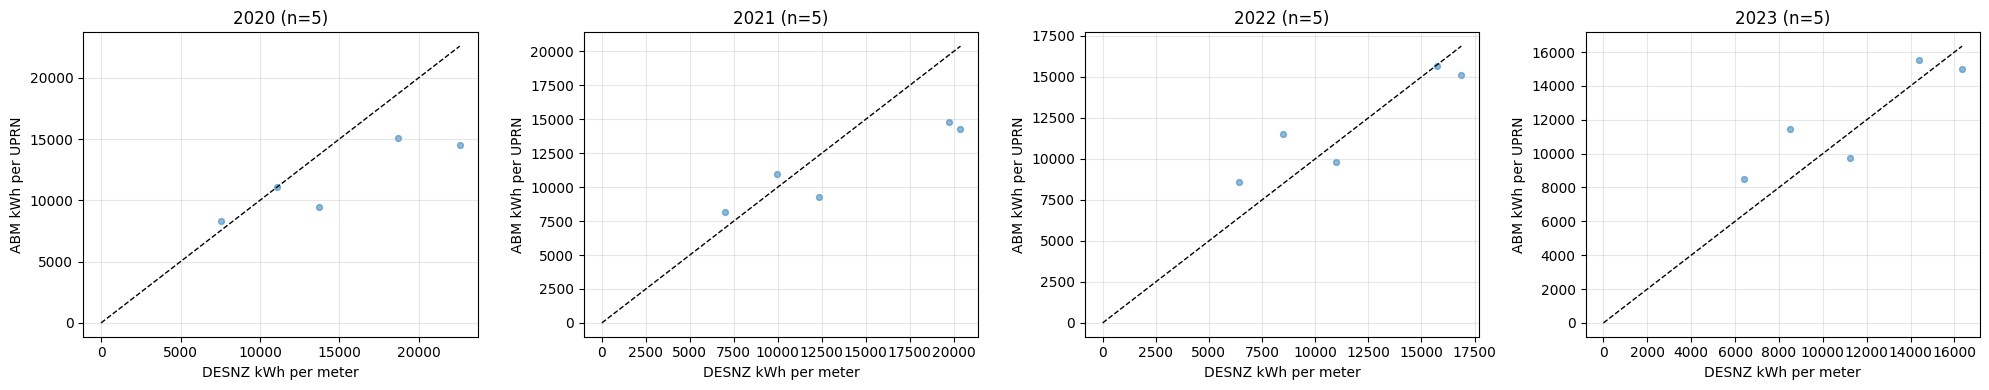

<Figure size 600x400 with 0 Axes>

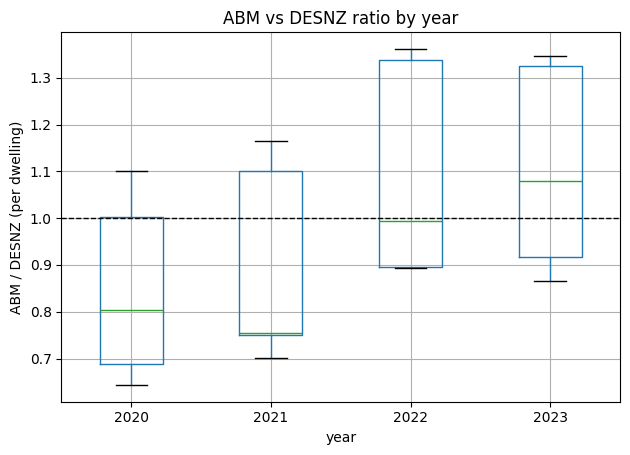

In [15]:
years_sorted = sorted(cmp['year'].unique())
fig, axes = plt.subplots(1, len(years_sorted), figsize=(5*len(years_sorted),4), sharex=False, sharey=False)
if len(years_sorted)==1:
    axes=[axes]
for ax, yr in zip(axes, years_sorted):
    sub = cmp[cmp['year']==yr]
    ax.scatter(sub['desnz_kwh_per_dw'], sub['abm_kwh_per_dw'], alpha=0.5, s=18)
    mx = max(sub['desnz_kwh_per_dw'].max(), sub['abm_kwh_per_dw'].max())
    ax.plot([0,mx],[0,mx],'k--',lw=1)
    ax.set_title(f"{yr} (n={len(sub)})")
    ax.set_xlabel('DESNZ kWh per meter')
    ax.set_ylabel('ABM kWh per UPRN')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
cmp.boxplot(column='ratio', by='year')
plt.axhline(1.0, color='k', linestyle='--', lw=1)
plt.ylabel('ABM / DESNZ (per dwelling)')
plt.title('ABM vs DESNZ ratio by year')
plt.suptitle(''); plt.tight_layout(); plt.show()


In [16]:
%pip install -e ..
import household_energy, inspect
print(household_energy.__file__)   # should point into your repo, not esa_mesa/lib/…


Obtaining file:///Users/abeltran/Documents/GitHub/spdt_abm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for household-energy-abm (pyproject.toml) ... done
  Created wheel for household-energy-abm: filename=household_energy_abm-0.1.0-0.editable-py3-none-any.whl size=3292 sha256=b69aba69af553b274657f2dc92834cb79bf46f63440f859700520698d95cf891
  Stored in directory: /private/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/pip-ephem-wheel-cache-w9gkzyya/wheels/fb/96/68/31e0625d51bb91c626bd221f2681222b47b077ba25374df64f
Successfully built household-energy-abm
  Attempting uninstall: household-energy-abm
    Found existing installation: household-energy-abm 0.1.0
    Uninstalling household-energy-abm-0.1.0:
      Successfully uninstalled household-energy-abm-0.1.0

[notice] A new release of pip is available: 23.

In [17]:
# Inspect current heat-slope and heating caps
attrs = [
    "heat_slope_area_exp",
    "heat_slope_min",
    "heat_slope_max",
    "max_heat_kwh_per_hour",
    "heating_slope_kWh_per_deg",
]
print({k: getattr(model, k, None) for k in attrs})

# Also show the top/bottom household slopes to confirm recompute
slopes = [getattr(h, "heat_slope_kWh_per_deg", None) for h in model.household_agents]
print("Household slope min/max:", min(slopes), max(slopes))

import household_energy, inspect
print("household_energy from:", household_energy.__file__)


NameError: name 'model' is not defined

In [ ]:
from household_energy.model import EnergyModel
m = EnergyModel(gdf=sub_gdf, climate_parquet=CLIMATE, climate_start=start,
                collect_agent_level=True, agent_collect_every=1)
print({
    "area_exp": m.heat_slope_area_exp,
    "slope_min": m.heat_slope_min,
    "slope_max": m.heat_slope_max,
    "max_heat_kwh_per_hour": m.max_heat_kwh_per_hour,
    "max_total":m.max_total_kwh_per_hour
})


NameError: name 'sub_gdf' is not defined

In [ ]:
# force cap/hyperparams for this run
model.heat_slope_area_exp   = 0.6
model.heat_slope_min        = 0.0
model.heat_slope_max        = 0.10
model.max_heat_kwh_per_hour = 20.0

# recompute per-house slopes with these settings
for h in model.household_agents:
    h.heat_slope_kWh_per_deg = h._compute_heat_slope(model.heating_slope_kWh_per_deg)

# sanity print
print({
    "area_exp": model.heat_slope_area_exp,
    "slope_min": model.heat_slope_min,
    "slope_max": model.heat_slope_max,
    "max_heat_kwh_per_hour": model.max_heat_kwh_per_hour,
    "house_slope_min": min(getattr(h,"heat_slope_kWh_per_deg",0) for h in model.household_agents),
    "house_slope_max": max(getattr(h,"heat_slope_kWh_per_deg",0) for h in model.household_agents),
})


NameError: name 'model' is not defined

In [ ]:
from household_energy.model import EnergyModel
m = EnergyModel(gdf=sub_gdf, climate_parquet=CLIMATE, climate_start=start, collect_agent_level=True, agent_collect_every=1)
print(m.max_heat_kwh_per_hour, m.heat_slope_max, m.heat_slope_area_exp)


NameError: name 'sub_gdf' is not defined

In [ ]:
## Debug run: single high-ratio LSOA with agents (one month)
from household_energy.climate import ClimateField
from household_energy.model import EnergyModel

# pick target
try:
    TARGET_LSOA = hi_lsoas[0]
except Exception:
    TARGET_LSOA = cmp.sort_values('ratio', ascending=False)[LSOA_COL].iloc[0]
print(f"Target LSOA: {TARGET_LSOA}")

DEBUG_OUTDIR = Path('results_lsoa') / TARGET_LSOA / f"run_debug_agents_{pd.Timestamp.utcnow():%Y%m%d}"
DEBUG_OUTDIR.mkdir(parents=True, exist_ok=True)

# filter dwellings
sub_gdf = gdf[gdf[LSOA_COL].astype(str) == TARGET_LSOA].copy()
print(f"Households in run: {len(sub_gdf):,}")

# one-month window (Jan 2023)
cf = ClimateField(CLIMATE)
start = pd.Timestamp('2023-07-01T00:00:00Z')
end = pd.Timestamp('2023-08-01T00:00:00Z')
i0 = cf.time_index_for(start)
i1 = cf.time_index_for(end)
T_hours = i1 - i0
start = pd.to_datetime(cf.times[i0], utc=True)

model = EnergyModel(
    gdf=sub_gdf,
    climate_parquet=CLIMATE,
    climate_start=start,
    local_tz='Europe/London',
    collect_agent_level=True,
    agent_collect_every=1,
)

for _ in range(T_hours):
    model.step()

mdl = model.model_dc.get_model_vars_dataframe().copy()
mdl['hour_start_utc'] = start + pd.to_timedelta(mdl.index - 1, unit='h')
mdl = mdl.set_index('hour_start_utc').iloc[1:]
mdl.to_parquet(DEBUG_OUTDIR / 'model_timeseries.parquet')

agent_df = model.agent_dc.get_agent_vars_dataframe()
agent_df.to_parquet(DEBUG_OUTDIR / 'agent_timeseries.parquet')
print('Saved agent_timeseries.parquet')
print('Outputs written to', DEBUG_OUTDIR)

# Spike analysis
agent_df = pd.read_parquet(DEBUG_OUTDIR / 'agent_timeseries.parquet').reset_index()
agent_df = agent_df[agent_df['agent_type'].str.lower() == 'household']
agent_df['month_kwh'] = agent_df.groupby('AgentID')['energy_consumption'].transform('sum')
spikes = (
    agent_df.groupby('AgentID')['energy_consumption']
        .agg(max_hour='max', mean_hour='mean', month_kwh='sum')
        .reset_index()
)
# attach features
lk_cols = ['UPRN', 'property_type', 'sap_rating', 'floor_area_m2', 'main_fuel_type', 'main_heating_system']
lk = sub_gdf[[c for c in lk_cols if c in sub_gdf.columns]].copy()
lk['UPRN'] = lk['UPRN'].astype(str)
spikes = spikes.merge(lk, left_on='AgentID', right_on='UPRN', how='left')

print('Top 30 dwellings by peak hourly kWh (Jan 2023):')
display(spikes.sort_values('max_hour', ascending=False).head(30))


Target LSOA: E01035614
Households in run: 1,394
Saved agent_timeseries.parquet
Outputs written to results_lsoa/E01035614/run_debug_agents_20260130
Top 30 dwellings by peak hourly kWh (Jan 2023):


,AgentID,max_hour,mean_hour,month_kwh,UPRN,property_type,sap_rating,floor_area_m2,main_fuel_type,main_heating_system
228,4510739613,8.445801,6.181885,4605.503964,4510739613,detached house,80,289.00,mains gas,boiler
198,4510737336,8.270418,6.120378,4559.681390,4510737336,detached house,80,270.00,mains gas,boiler
216,4510739601,8.241801,6.113016,4554.197065,4510739601,detached house,80,270.00,mains gas,boiler
224,4510739609,8.241801,6.027667,4490.611629,4510739609,detached house,80,289.00,mains gas,boiler
266,4510741798,8.235991,6.063598,4517.380406,4510741798,detached house,88,342.00,mains gas,boiler
...,...,...,...,...,...,...,...,...,...,...
44,4510729703,8.003111,5.991143,4463.401796,4510729703,semi-detached house,80,204.49,oil,boiler
263,4510741647,8.001369,5.967316,4445.650427,4510741647,detached house,85,316.00,oil,boiler
721,4510757565,7.996569,5.956666,4437.715878,4510757565,detached house,87,289.00,mains gas,boiler
206,4510738088,7.994721,6.005694,4474.242180,4510738088,detached house,81,220.00,mains gas,boiler


In [ ]:
## EPC cross-check for spiky dwellings (use raw certificates CSV)
EPC_CSV = "/Users/abeltran/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/dt/esa/sample/data/open_inputs/domestic-E08000021-Newcastle-upon-Tyne/certificates.csv"

import pandas as pd
print('Loading EPC CSV...')
epc = pd.read_csv(EPC_CSV, low_memory=False)
epc.columns

Loading EPC CSV...


Index(['LMK_KEY', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY',
       'POTENTIAL_ENERGY_EFFICIENCY', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'LODGEMENT_DATE', 'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'ENERGY_CONSUMPTION_POTENTIAL', 'CO2_EMISSIONS_CURRENT',
       'CO2_EMISS_CURR_PER_FLOOR_AREA', 'CO2_EMISSIONS_POTENTIAL',
       'LIGHTING_COST_CURRENT', 'LIGHTING_COST_POTENTIAL',
       'HEATING_COST_CURRENT', 'HEATING_COST_POTENTIAL',
       'HOT_WATER_COST_CURRENT', 'HOT_WATER_COST_POTENTIAL',
       'TOTAL_FLOOR_AREA', 'ENERGY_TARIFF', 'MAINS_GAS_FLAG', 'FLOOR_LEVEL',
       'FLAT_TOP_STOREY', 'FLAT_STOREY_COUNT', 'MAIN_HEATING_CONTROLS',
       'MULTI_GLAZE_PROPORTION', 'GLAZED_TYPE', 'GLAZED_AREA',
      

In [ ]:
## EPC cross-check for spiky dwellings (use raw certificates CSV)
EPC_CSV = "/Users/abeltran/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/dt/esa/sample/data/open_inputs/domestic-E08000021-Newcastle-upon-Tyne/certificates.csv"

import pandas as pd
print('Loading EPC CSV...')
epc = pd.read_csv(EPC_CSV, low_memory=False)

# normalize column names
cols_lower = {c: c.lower() for c in epc.columns}
epc.rename(columns=cols_lower, inplace=True)

# UPRN as int string
uprn_series = pd.to_numeric(epc.get('uprn'), errors='coerce').astype('Int64')

# build EPC frame
E = pd.DataFrame({
    'UPRN': uprn_series.astype(str),
    'property_type': epc.get('property_type'),
    'built_form': epc.get('built_form'),
    'floor_area_m2': pd.to_numeric(epc.get('total_floor_area'), errors='coerce'),
    'sap_rating': pd.to_numeric(epc.get('current_energy_efficiency'), errors='coerce'),
    'sap_band_ord': epc.get('current_energy_rating'),
    'energy_consumption_current': pd.to_numeric(epc.get('energy_consumption_current'), errors='coerce'),
})
E['energy_cal_kwh'] = (E['energy_consumption_current'] * E['floor_area_m2']).round(1)

if 'spikes' not in globals():
    raise RuntimeError("Run the debug agent run to define 'spikes' first")
spike_ids = spikes[['AgentID']].rename(columns={'AgentID':'UPRN'})
spike_ids['UPRN'] = spike_ids['UPRN'].astype(str)

merged_epc = spike_ids.merge(E, on='UPRN', how='left')
print(f"Merged EPC rows: {len(merged_epc)}")




Loading EPC CSV...
Merged EPC rows: 1487


In [ ]:
print('EPC energy_cal_kwh summary for spiky dwellings:')
print(merged_epc['energy_cal_kwh'].describe())

print('Missing energy_cal_kwh count:')
print(merged_epc['energy_cal_kwh'].isna().sum())

print('Sample merged rows:')
display(merged_epc.head())

EPC energy_cal_kwh summary for spiky dwellings:
count      1487.000000
mean      12075.134499
std        7257.596597
min          99.000000
25%        8186.000000
50%       10440.000000
75%       14112.000000
max      106990.000000
Name: energy_cal_kwh, dtype: float64
Missing energy_cal_kwh count:
0
Sample merged rows:


,UPRN,property_type,built_form,floor_area_m2,sap_rating,sap_band_ord,energy_consumption_current,energy_cal_kwh
0,4510000873,House,Detached,151.0,84,B,88,13288.0
1,4510000899,House,Detached,168.0,85,B,86,14448.0
2,4510000915,House,Detached,226.0,87,B,75,16950.0
3,4510001248,House,Detached,192.0,86,B,80,15360.0
4,4510001517,House,Detached,167.0,85,B,81,13527.0


In [ ]:
spikes

,AgentID,max_hour,mean_hour,month_kwh,UPRN,property_type,sap_rating,floor_area_m2,main_fuel_type,main_heating_system
0,4510000873,6.808718,6.268638,4670.135135,4510000873,detached house,84,151.0,mains gas,boiler
1,4510000899,7.908428,7.266586,5413.606477,4510000899,detached house,85,168.0,mains gas,boiler
2,4510000915,9.734768,9.211441,6862.523664,4510000915,detached house,87,226.0,mains gas,boiler
3,4510001248,9.038077,8.352735,6222.787246,4510001248,detached house,86,192.0,mains gas,boiler
4,4510001517,7.513174,6.907359,5145.982466,4510001517,detached house,85,167.0,mains gas,boiler
...,...,...,...,...,...,...,...,...,...,...
1389,4510763303,1.439346,1.047622,780.478128,4510763303,semi-detached house,90,79.0,mains gas,boiler
1390,4510763304,1.565304,1.189210,885.961722,4510763304,semi-detached house,91,85.0,mains gas,boiler
1391,4510763305,1.075218,0.707401,527.013553,4510763305,mid-terraced house,91,63.0,mains gas,boiler
1392,4510763306,1.099218,0.763521,568.823020,4510763306,mid-terraced house,91,63.0,mains gas,boiler


In [ ]:
from pathlib import Path

# Clean merge with EPC + HIDP socio features
spikes_clean = spikes.copy()
spikes_clean['UPRN'] = spikes_clean['UPRN'].astype(str)
merged_epc['UPRN'] = merged_epc['UPRN'].astype(str)

# socio columns from enriched gdf (after HIDP merge)
hidp_cols = [c for c in [
    'hidp','hh_n_people','hh_children','hh_income_band','hh_edu_detail',
    'dwelling_bucket','tenure','schedule_type'
] if c in gdf.columns]
gdf_socio = gdf[['UPRN'] + hidp_cols].copy() if 'UPRN' in gdf.columns else gdf[hidp_cols].copy()
if 'UPRN' in gdf_socio:
    gdf_socio['UPRN'] = gdf_socio['UPRN'].astype(str)

spikes_epc = spikes_clean.merge(merged_epc, on='UPRN', how='left', suffixes=('', '_epc'))
if hidp_cols:
    spikes_epc = spikes_epc.merge(gdf_socio, on='UPRN', how='left')

# EPC-derived hourly base (calibrated path: no multipliers)
spikes_epc['epc_hourly_base'] = spikes_epc['energy_cal_kwh'] / (365 * 24)

keep_cols = [
    'UPRN', 'max_hour', 'mean_hour', 'month_kwh',
    'energy_cal_kwh', 'energy_consumption_current', 'floor_area_m2',
    'property_type', 'built_form', 'sap_rating',
    'main_fuel_type', 'main_heating_system', 'epc_hourly_base'
] + hidp_cols
keep_cols = [c for c in keep_cols if c in spikes_epc.columns]
spikes_view = spikes_epc[keep_cols]

print('Spikes merged shape:', spikes_view.shape)
display(spikes_view.head(20))

# Save to CSV
out_csv = Path('results_lsoa') / f"spikes_epc_{pd.Timestamp.utcnow():%Y%m%d%H%M%S}.csv"
spikes_view.to_csv(out_csv, index=False)
print('Saved to', out_csv)


Spikes merged shape: (1487, 21)


,UPRN,max_hour,mean_hour,month_kwh,energy_cal_kwh,energy_consumption_current,floor_area_m2,property_type,built_form,sap_rating,main_fuel_type,main_heating_system,epc_hourly_base,hidp,hh_n_people,hh_children,hh_income_band,hh_edu_detail,dwelling_bucket,tenure,schedule_type
0,4510000873,8.191758,7.120421,5304.713280,13288.0,88,151.0,detached house,Detached,84,mains gas,boiler,1.516895,1.250853e+09,4.0,True,NaN,upper_further,detached_house,NaN,family_with_children
1,4510000899,8.413901,7.016250,5227.106499,14448.0,86,168.0,detached house,Detached,85,mains gas,boiler,1.649315,1.321036e+09,1.0,False,NaN,upper_further,detached_house,NaN,working_adult_household
2,4510000915,9.211688,8.069090,6011.472384,16950.0,75,226.0,detached house,Detached,87,mains gas,boiler,1.934932,1.414482e+08,1.0,False,q5_highest,postgrad_or_degree,detached_house,NaN,retired_household
3,4510001248,8.928965,7.458790,5556.798662,15360.0,80,192.0,detached house,Detached,86,mains gas,boiler,1.753425,7.768796e+08,3.0,True,NaN,upper_further,detached_house,NaN,working_adult_household
4,4510001517,8.419618,7.165178,5338.057407,13527.0,81,167.0,detached house,Detached,85,mains gas,boiler,1.544178,4.323100e+08,2.0,False,NaN,postgrad_or_degree,detached_house,NaN,dual_earner_household
5,4510001535,9.227885,7.582073,5648.644340,17784.0,72,247.0,detached house,Detached,87,mains gas,boiler,2.030137,4.307120e+08,1.0,False,NaN,postgrad_or_degree,detached_house,NaN,working_adult_household
6,4510001537,9.211688,7.438272,5541.512987,16950.0,75,226.0,detached house,Detached,87,mains gas,boiler,1.934932,3.661052e+08,1.0,False,q5_highest,postgrad_or_degree,detached_house,NaN,working_adult_household
7,4510001538,8.666177,7.453608,5552.937826,14175.0,81,175.0,detached house,Detached,86,mains gas,boiler,1.618151,8.223240e+08,4.0,True,q1_lowest,postgrad_or_degree,detached_house,NaN,family_with_children
8,4510001539,4.237849,3.535284,2633.786423,9000.0,100,90.0,detached house,Detached,83,mains gas,boiler,1.027397,7.065268e+08,4.0,True,NaN,postgrad_or_degree,detached_house,NaN,family_with_children
9,4510001540,6.970505,5.805733,4325.270720,11475.0,85,135.0,detached house,Detached,85,mains gas,boiler,1.309932,3.652076e+08,1.0,False,q2_low,upper_further,detached_house,NaN,working_adult_household


Saved to results_lsoa/spikes_epc_20260130125435.csv


In [ ]:
# Multipliers / caps used by the ABM (property type & floor area)
from pathlib import Path
import yaml, numpy as np, pandas as pd
from household_energy.agent import PROPERTY_TYPE_MULTIPLIER

# 1) Property-type multipliers (used in baseline + heating slope/capacity)
print("Property-type multipliers:")
for k, v in PROPERTY_TYPE_MULTIPLIER.items():
    print(f"  {k:50s} -> {v:4.2f}")

# 2) Model power/cap defaults (pulled from code fallbacks in model.py)
model_defaults = {
    "heat_slope_area_exp": 0.6,
    "heat_slope_min": 0.0,
    "heat_slope_max": 0.10,
    "max_heat_kwh_per_hour": 20.0,
    "max_total_kwh_per_hour": 20.0,
    "max_base_kwh_per_hour": 5.0,
    "base_heat_capacity": 8.0,
    "heat_capacity_area_exp": 0.5,
    "min_heat_capacity": 4.0,
}

# If your active config overrides any of these, load them from YAML
cfg_path = Path("household_energy/config_defaults.yaml")
if cfg_path.exists():
    cfg = yaml.safe_load(cfg_path.read_text())
    m = cfg.get("model", {}) or {}
    for k in list(model_defaults):
        model_defaults[k] = m.get(k, model_defaults[k])

print("\nModel caps / scaling (active values):")
for k, v in model_defaults.items():
    print(f"  {k:25s}: {v}")

# 3) Floor-area scaling examples (for the heating slope exponent)
def area_scale(area_m2, exp=model_defaults["heat_slope_area_exp"], lo=0.6, hi=1.6):
    return float(np.clip((area_m2 / 90.0) ** exp, lo, hi))

areas = [60, 90, 120, 180, 300]
print("\nFloor-area factor examples (slope scale):")
for a in areas:
    print(f"  {a:4.0f} m² -> {area_scale(a):.3f}")


Property-type multipliers:
  mid-terraced house                                 -> 1.00
  semi-detached house                                -> 1.25
  small block of flats/dwelling converted in to flats -> 0.80
  large block of flats                               -> 0.70
  block of flats                                     -> 0.70
  end-terraced house                                 -> 1.05
  detached house                                     -> 1.80
  flat in mixed use building                         -> 0.85

Model caps / scaling (active values):
  heat_slope_area_exp      : 0.6
  heat_slope_min           : 0.0
  heat_slope_max           : 0.1
  max_heat_kwh_per_hour    : 20.0
  max_total_kwh_per_hour   : 20.0
  max_base_kwh_per_hour    : 5.0
  base_heat_capacity       : 8.0
  heat_capacity_area_exp   : 0.5
  min_heat_capacity        : 4.0

Floor-area factor examples (slope scale):
    60 m² -> 0.784
    90 m² -> 1.000
   120 m² -> 1.188
   180 m² -> 1.516
   300 m² -> 1.600



## ABM baseline/heating changes (applied 2026-01-30)

- Baseline energy now uses a fixed, meter-anchored load (0.40 kWh/h) with mild area + property-type scaling and a hard cap of 1.5 kWh/h.
- EPC-derived annuals no longer scale the baseline; structural levers (SAP, envelope, fuel) now affect only heating response.
- Property-type multipliers split: `property_type_mult_base` for baseline, `pt_heat_mult` (and `PROPERTY_TYPE_MULT_HEAT`) for heating (detached 1.20, semi 1.10, flats 0.85–0.90).
- Duty-cycle heating model retained; total hourly cap still at 20 kWh/h with per-component clip diagnostics (`base_kwh`, `heat_kwh`, `spike_kwh`, `cap_clip_*`).
- Key config knobs live in `household_energy/config_defaults.yaml` under `model:` (baseline anchor, area exponents, caps).
